# Telco Customer Churn - End to End ML Project


This notebook presents an end-to-end Exploratory Data Analysis (EDA) and predictive modeling pipeline. Our main purpose is to explain and predict the Churn variable—our target—by uncovering hidden patterns and statistical relationships within the rest of the dataset's features.


## Objective
Predict whether a customer will churn (leave the telecom company).

---

## Project Pipeline


### 1. Data Cleaning
Handling missing values, inconsistencies, and data types.

### 2. Data Understanding & EDA
Exploration of distributions, missing values, and relationships.

### 3. Feature Engineering
Creation of meaningful variables and encoding categorical features.

### 4. Modeling
Training and comparing different machine learning models.

### 5. Evaluation
Use of metrics such as ROC-AUC, Precision, Recall, F1-score.

### 6. Model Interpretation
Understanding feature importance and model decisions (e.g. SHAP).

---

## Deployment

### 7. API Development
Expose the trained model using a REST API (FastAPI or Flask).

- Endpoint: `/predict`
- Input: customer features in JSON format
- Output: churn probability

### 8. Simple Web App
Build a small interface using Streamlit where users can input customer data and get predictions.

---

## Tech Stack
- Python
- Pandas, NumPy
- Scikit-learn
- Matplotlib / Seaborn
- FastAPI or Flask
- Streamlit

## Libraries

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn
# !pip install xgboost
# !pip install lightgbm
# !pip install jinja2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import mannwhitneyu, chi2_contingency
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore') # Oculta avisos durante el GridSearch

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")



## Data Ingestion & Loading

In [3]:
df = pd.read_csv("C:\\Users\\Usuario\\Desktop\\Proyectos\\telco-Costumer\\dataset\\WA_Fn-UseC_-Telco-Customer-Churn.csv")


## Data Overview

In this section we explore the dataset structure, dimensions, and data types to understand what we are working with.

In [4]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


We analyze the descriptive statistics of the numerical features to verify data integrity and rule out logical inconsistencies, such as negative values.

## 1. Data Cleaning

Now we are going to verify if the non-null results are correct by using a function:


In [7]:



print("GENERAL VARIABLE AUDIT (COMPACT VERSION)\n")

for col in df.columns:
    real_nulls = df[col].isnull().sum()
    hidden_nulls = 0
    hidden_values_list = []
    
    # Robust text type check
    if pd.api.types.is_string_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
        # Create a mask to locate the exact rows with hidden nulls
        hidden_mask = df[col].apply(lambda x: pd.notnull(x) and str(x).strip() == "")
        hidden_nulls = hidden_mask.sum()
        
        # If found, extract the exact unique string representations
        if hidden_nulls > 0:
            hidden_values_list = df[col][hidden_mask].unique().tolist()
            
    total_issues = real_nulls + hidden_nulls
    
    # Alerts or confirmations
    if total_issues > 0:
        # Use repr() to make spaces visible in the print statement (e.g., ' ' instead of invisible space)
        hidden_types_str = f" -> Types found: {[repr(v) for v in hidden_values_list]}" if hidden_nulls > 0 else ""
        print(f"🔴 ALERT in '{col}': {real_nulls} NaN | {hidden_nulls} hidden spaces/empty strings.{hidden_types_str}")
    else:
        unique_values = df[col].unique().tolist() 
        
        if pd.api.types.is_numeric_dtype(df[col]):
            print(f"🟢 '{col}' (Numeric) -> OK. Range: [{df[col].min()} to {df[col].max()}]")
        elif len(unique_values) <= 10:
            print(f"🟢 '{col}' (Categorical) -> OK. Categories: {unique_values}")
        else:
            print(f"🟢 '{col}' (Text/ID) -> OK. {len(unique_values)} distinct unique values.")

GENERAL VARIABLE AUDIT (COMPACT VERSION)

🟢 'customerID' (Text/ID) -> OK. 7043 distinct unique values.
🟢 'gender' (Categorical) -> OK. Categories: ['Female', 'Male']
🟢 'SeniorCitizen' (Numeric) -> OK. Range: [0 to 1]
🟢 'Partner' (Categorical) -> OK. Categories: ['Yes', 'No']
🟢 'Dependents' (Categorical) -> OK. Categories: ['No', 'Yes']
🟢 'tenure' (Numeric) -> OK. Range: [0 to 72]
🟢 'PhoneService' (Categorical) -> OK. Categories: ['No', 'Yes']
🟢 'MultipleLines' (Categorical) -> OK. Categories: ['No phone service', 'No', 'Yes']
🟢 'InternetService' (Categorical) -> OK. Categories: ['DSL', 'Fiber optic', 'No']
🟢 'OnlineSecurity' (Categorical) -> OK. Categories: ['No', 'Yes', 'No internet service']
🟢 'OnlineBackup' (Categorical) -> OK. Categories: ['Yes', 'No', 'No internet service']
🟢 'DeviceProtection' (Categorical) -> OK. Categories: ['No', 'Yes', 'No internet service']
🟢 'TechSupport' (Categorical) -> OK. Categories: ['No', 'Yes', 'No internet service']
🟢 'StreamingTV' (Categorical) -> 

This audit reveals hidden missing values that bypassed the initial .info() summary, identifying both the exact string characters used to mask them and the variables containing them.
Given that TotalCharges is the only variable with hidden missing values, we will analyze if this absence of data is explained by the clients' tenure (i.e., new customers who haven't generated their first bill yet).

In [8]:


# 1. Filter the rows where TotalCharges has hidden missing values
hidden_mask = df['TotalCharges'].apply(lambda x: str(x).strip() == "")
problematic_clients = df[hidden_mask]

# 2. Calculate the counts based on the 'tenure' value
tenure_zero_count = (problematic_clients['tenure'] == 0).sum()
tenure_not_zero_count = (problematic_clients['tenure'] != 0).sum()

# 3. Create a well-formatted DataFrame to summarize the findings
tenure_summary_table = pd.DataFrame({
    'Target Variable': ['TotalCharges (Hidden NaNs)'],
    'Count (tenure = 0)': [tenure_zero_count],
    'Count (tenure != 0)': [tenure_not_zero_count]
})

print("TENURE DISTRIBUTION FOR MISSING TotalCharges\n")
display(tenure_summary_table)


print("\nSAMPLE OF AFFECTED ROWS")
display(problematic_clients[['tenure', 'MonthlyCharges', 'TotalCharges']].head())


TENURE DISTRIBUTION FOR MISSING TotalCharges



,Target Variable,Count (tenure = 0),Count (tenure != 0)
0,TotalCharges (Hidden NaNs),11,0



SAMPLE OF AFFECTED ROWS


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,



As demonstrated above, the hidden missing values in `TotalCharges` belong exclusively to new customers (`tenure = 0`). Since they haven't been subscribed long enough to generate a bill, it is mathematically and logically correct to impute these empty spaces with a value of `0`. 

Finally, we will convert the column to a numeric data type to allow for statistical analysis and plotting.

Also, the `SeniorCitizen` feature is originally encoded as numeric (`0` and `1`). To ensure our Exploratory Data Analysis treats it properly as a categorical (dichotomous) variable, we will map these values to `'No'` and `'Yes'` to match the rest of the dataset's binary features.

In [9]:
# 1. Replace the exact empty space string with 0
df['TotalCharges'] = df['TotalCharges'].replace(" ", 0)

# 2. Convert the entire column to a numeric type (float64)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# 3. Verify the changes
print(f"Data type of TotalCharges is now: {df['TotalCharges'].dtype}")
print(f"Number of empty spaces left: {df['TotalCharges'].apply(lambda x: str(x).strip() == '').sum()} \n")








df_original = pd.read_csv('C:\\Users\\Usuario\\Desktop\\Proyectos\\telco-Costumer\\dataset\\WA_Fn-UseC_-Telco-Customer-Churn.csv') 
df['SeniorCitizen'] = df_original['SeniorCitizen']


df['SeniorCitizen'] = df['SeniorCitizen'].replace({0: 'No', 1: 'Yes'})


senior_summary = df['SeniorCitizen'].value_counts().reset_index()
senior_summary.columns = ['SeniorCitizen (Category)', 'Count']
print("SeniorCitizen Distribution After Recoding\n")
display(senior_summary)

Data type of TotalCharges is now: float64
Number of empty spaces left: 0 

SeniorCitizen Distribution After Recoding



,SeniorCitizen (Category),Count
0,No,5901
1,Yes,1142


## 2. Exploratory Data Analysis (EDA)

### 2.1 Univariate Visualizations

To understand the shape and distribution of our data, we will plot all the relevant variables. To keep the notebook clean and readable, the charts are displayed in a 2x2 grid format based on their data type:
- **Violin Plots** for continuous numerical variables.
- **Pie Charts** for dichotomous (binary) categorical variables.
- **Bar Charts** for discrete/multi-class categorical variables.

*Note: The `customerID` column is excluded from this visualization as it is a unique identifier without predictive value.*

--- CONTINUOUS VARIABLES ---


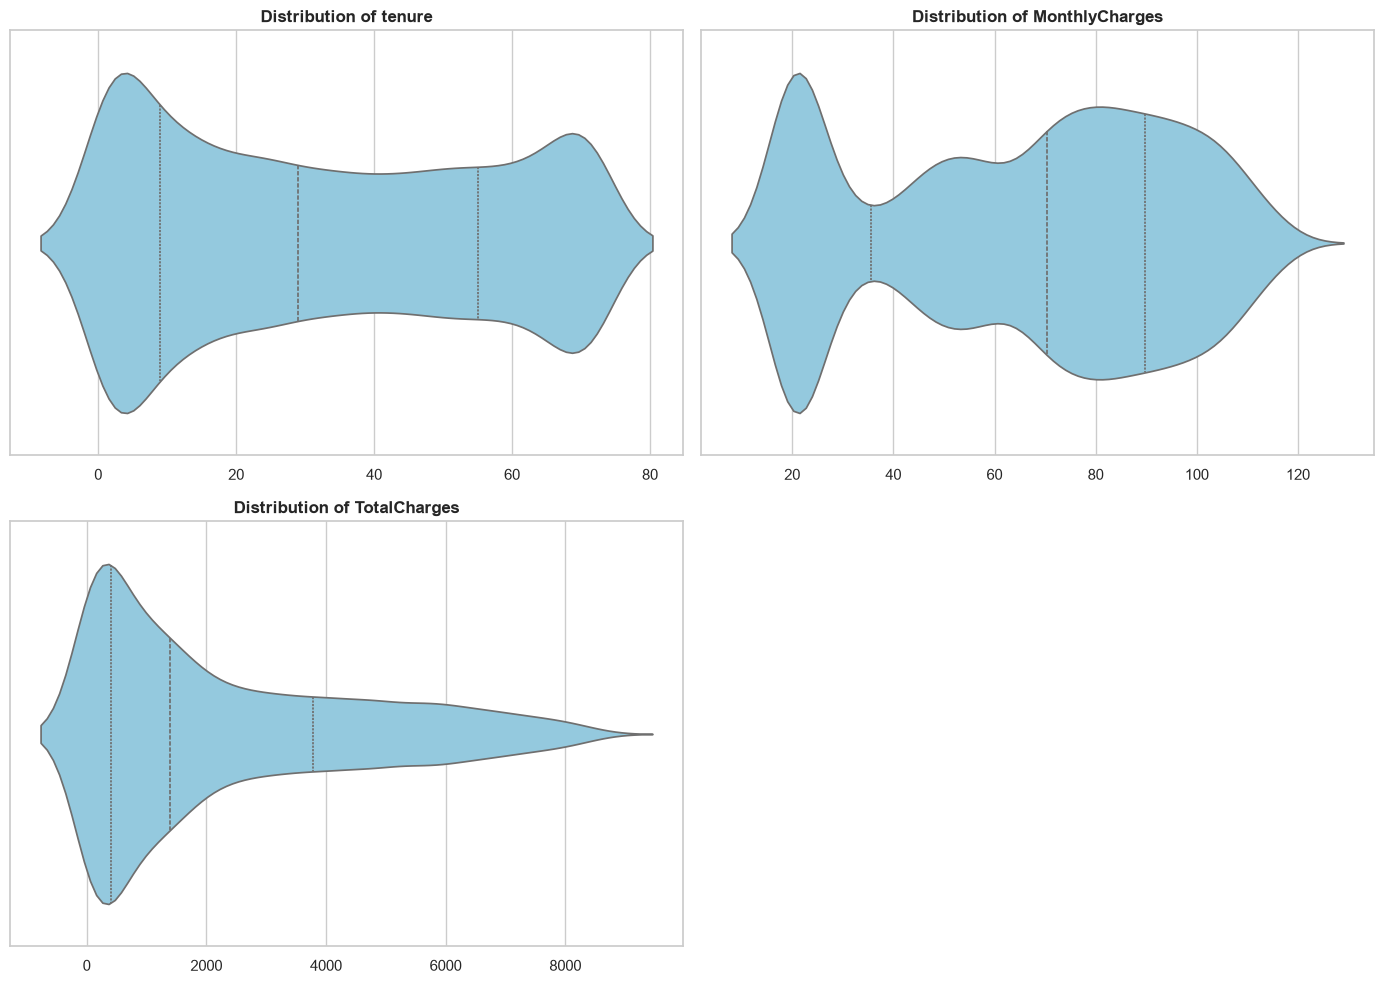

In [10]:


# Set global visualization style
sns.set_theme(style="whitegrid")

# Exclude customerID and classify variables
df_viz = df.drop(columns=['customerID'])

continuous_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']

binary_vars = [col for col in df_viz.columns if df_viz[col].nunique() == 2 and col not in continuous_vars]

discrete_vars = [col for col in df_viz.columns if df_viz[col].nunique() > 2 and col not in continuous_vars]


# CONTINUOUS VARIABLES: VIOLIN PLOTS (HORIZONTAL) 
print("--- CONTINUOUS VARIABLES ---")
fig, axes = plt.subplots(nrows=math.ceil(len(continuous_vars)/2), ncols=2, figsize=(14, 5 * math.ceil(len(continuous_vars)/2)))
axes = axes.flatten()

for i, col in enumerate(continuous_vars):
    # El cambio clave: x=df_viz[col] en lugar de y
    sns.violinplot(x=df_viz[col], ax=axes[i], color='skyblue', inner="quartile")
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('') 

# Hide any empty subplots
for j in range(i + 1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()



The violin plots reveal distinct behavioral patterns. The tenure distribution is distinctly bimodal, highlighting a polarity between newly acquired customers and long-term veterans. MonthlyCharges shows a trimodal distribution, strongly suggesting the existence of distinct pricing tiers or bundled service packages. Meanwhile, TotalCharges presents a positively skewed (right-skewed) distribution; this heavy concentration at the lower end is a logical byproduct of the large cohort of low-tenure customers who haven't yet accumulated high billing amounts.


--- DICHOTOMOUS VARIABLES ---


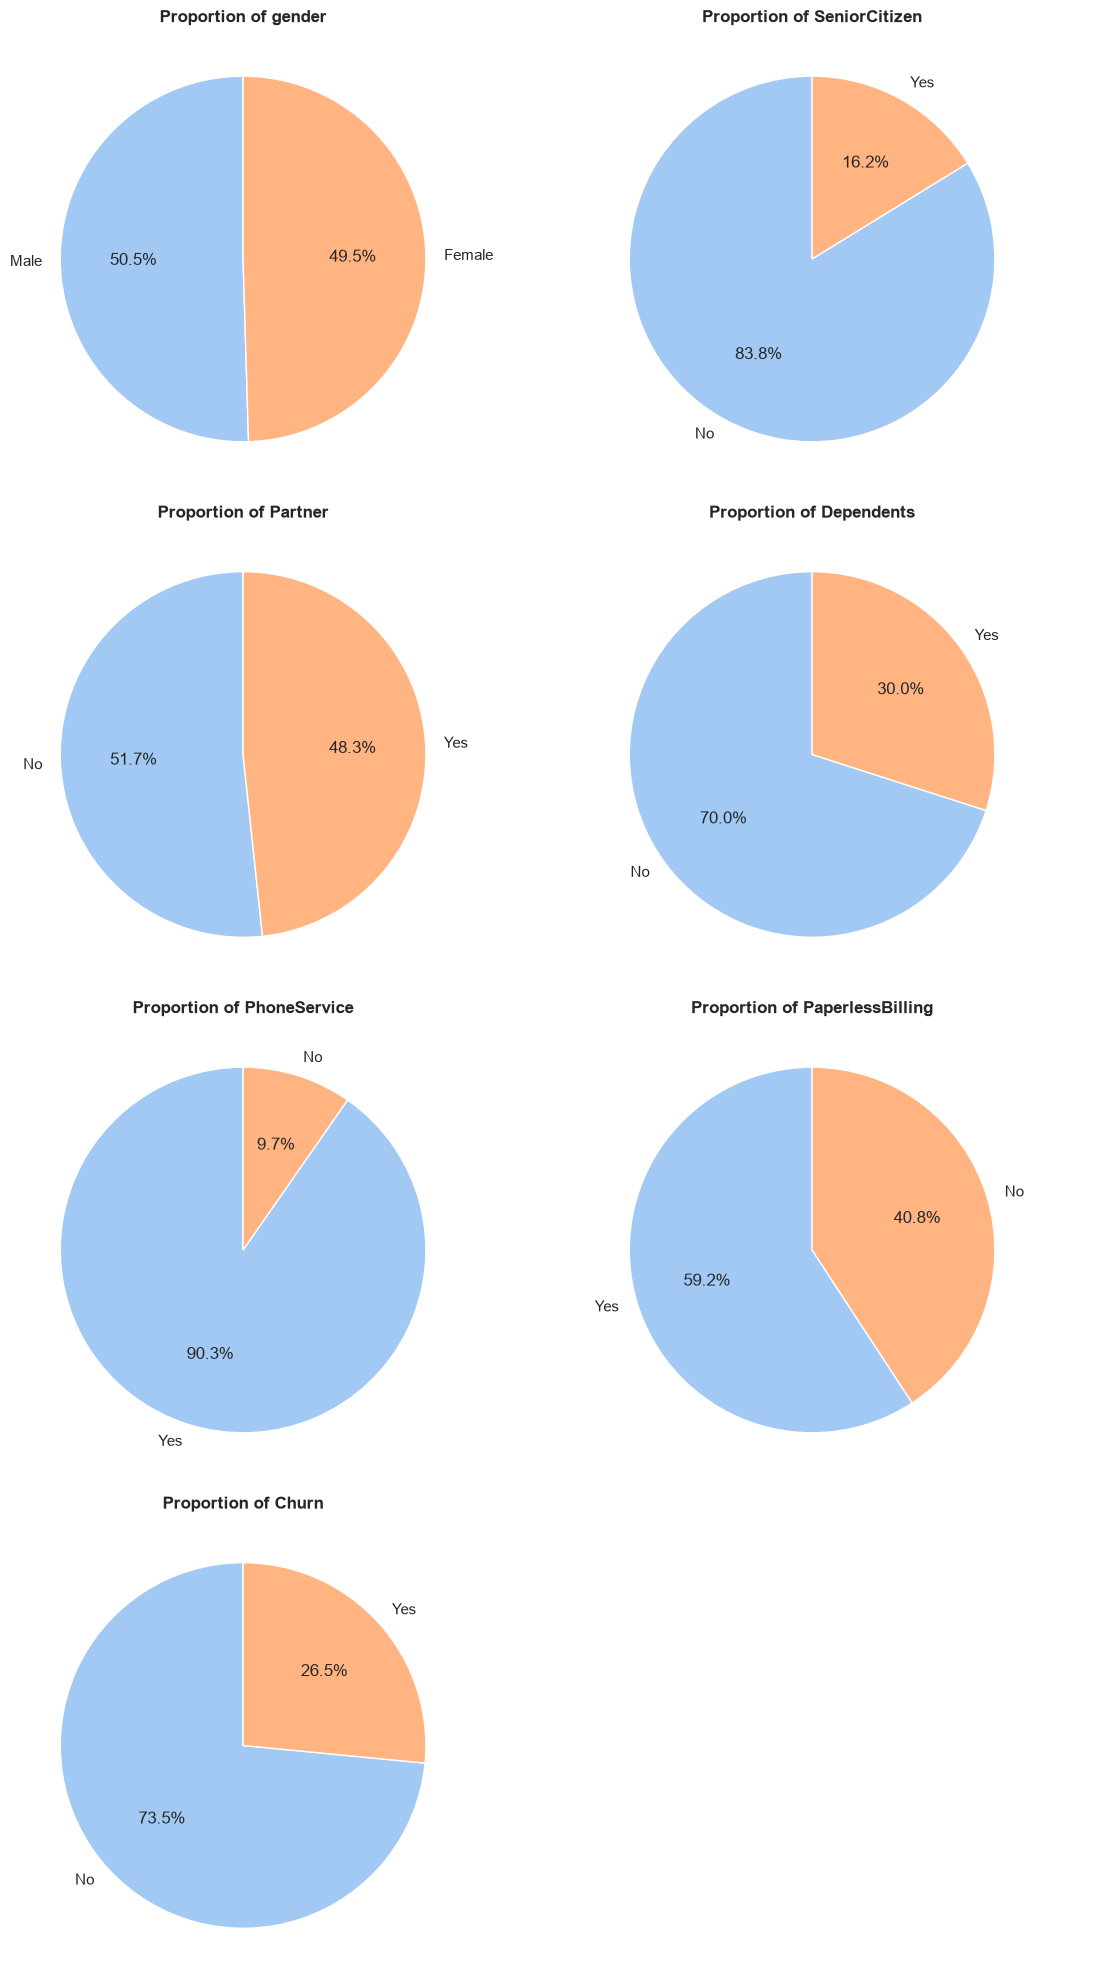

In [11]:

# DICHOTOMOUS VARIABLES: PIE CHARTS 
print("\n--- DICHOTOMOUS VARIABLES ---")
fig, axes = plt.subplots(nrows=math.ceil(len(binary_vars)/2), ncols=2, figsize=(12, 5 * math.ceil(len(binary_vars)/2)))
axes = axes.flatten()

for i, col in enumerate(binary_vars):
    counts = df_viz[col].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, 
                colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'white'})
    axes[i].set_title(f'Proportion of {col}', fontsize=12, fontweight='bold')

for j in range(i + 1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()


The categorical variables present varying degrees of distribution. Gender and Partner status are evenly distributed, showing no significant imbalance. Conversely, we observe notable disparities in other segments: the population is predominantly non-senior, and there is a clear minority of customers with dependents or without phone service. Regarding Paperless Billing, there is a slight majority using this service.

The Churn variable indicates whether a customer left the company within the last month. With a churn rate of 26.5%, the company is facing an extremely high attrition rate that threatens its long-term viability. This finding frames our project not just as a technical classification task, but as a critical business intervention: identifying the key drivers of this rapid churn to propose actionable retention strategies.


--- DISCRETE / MULTI-CLASS VARIABLES ---


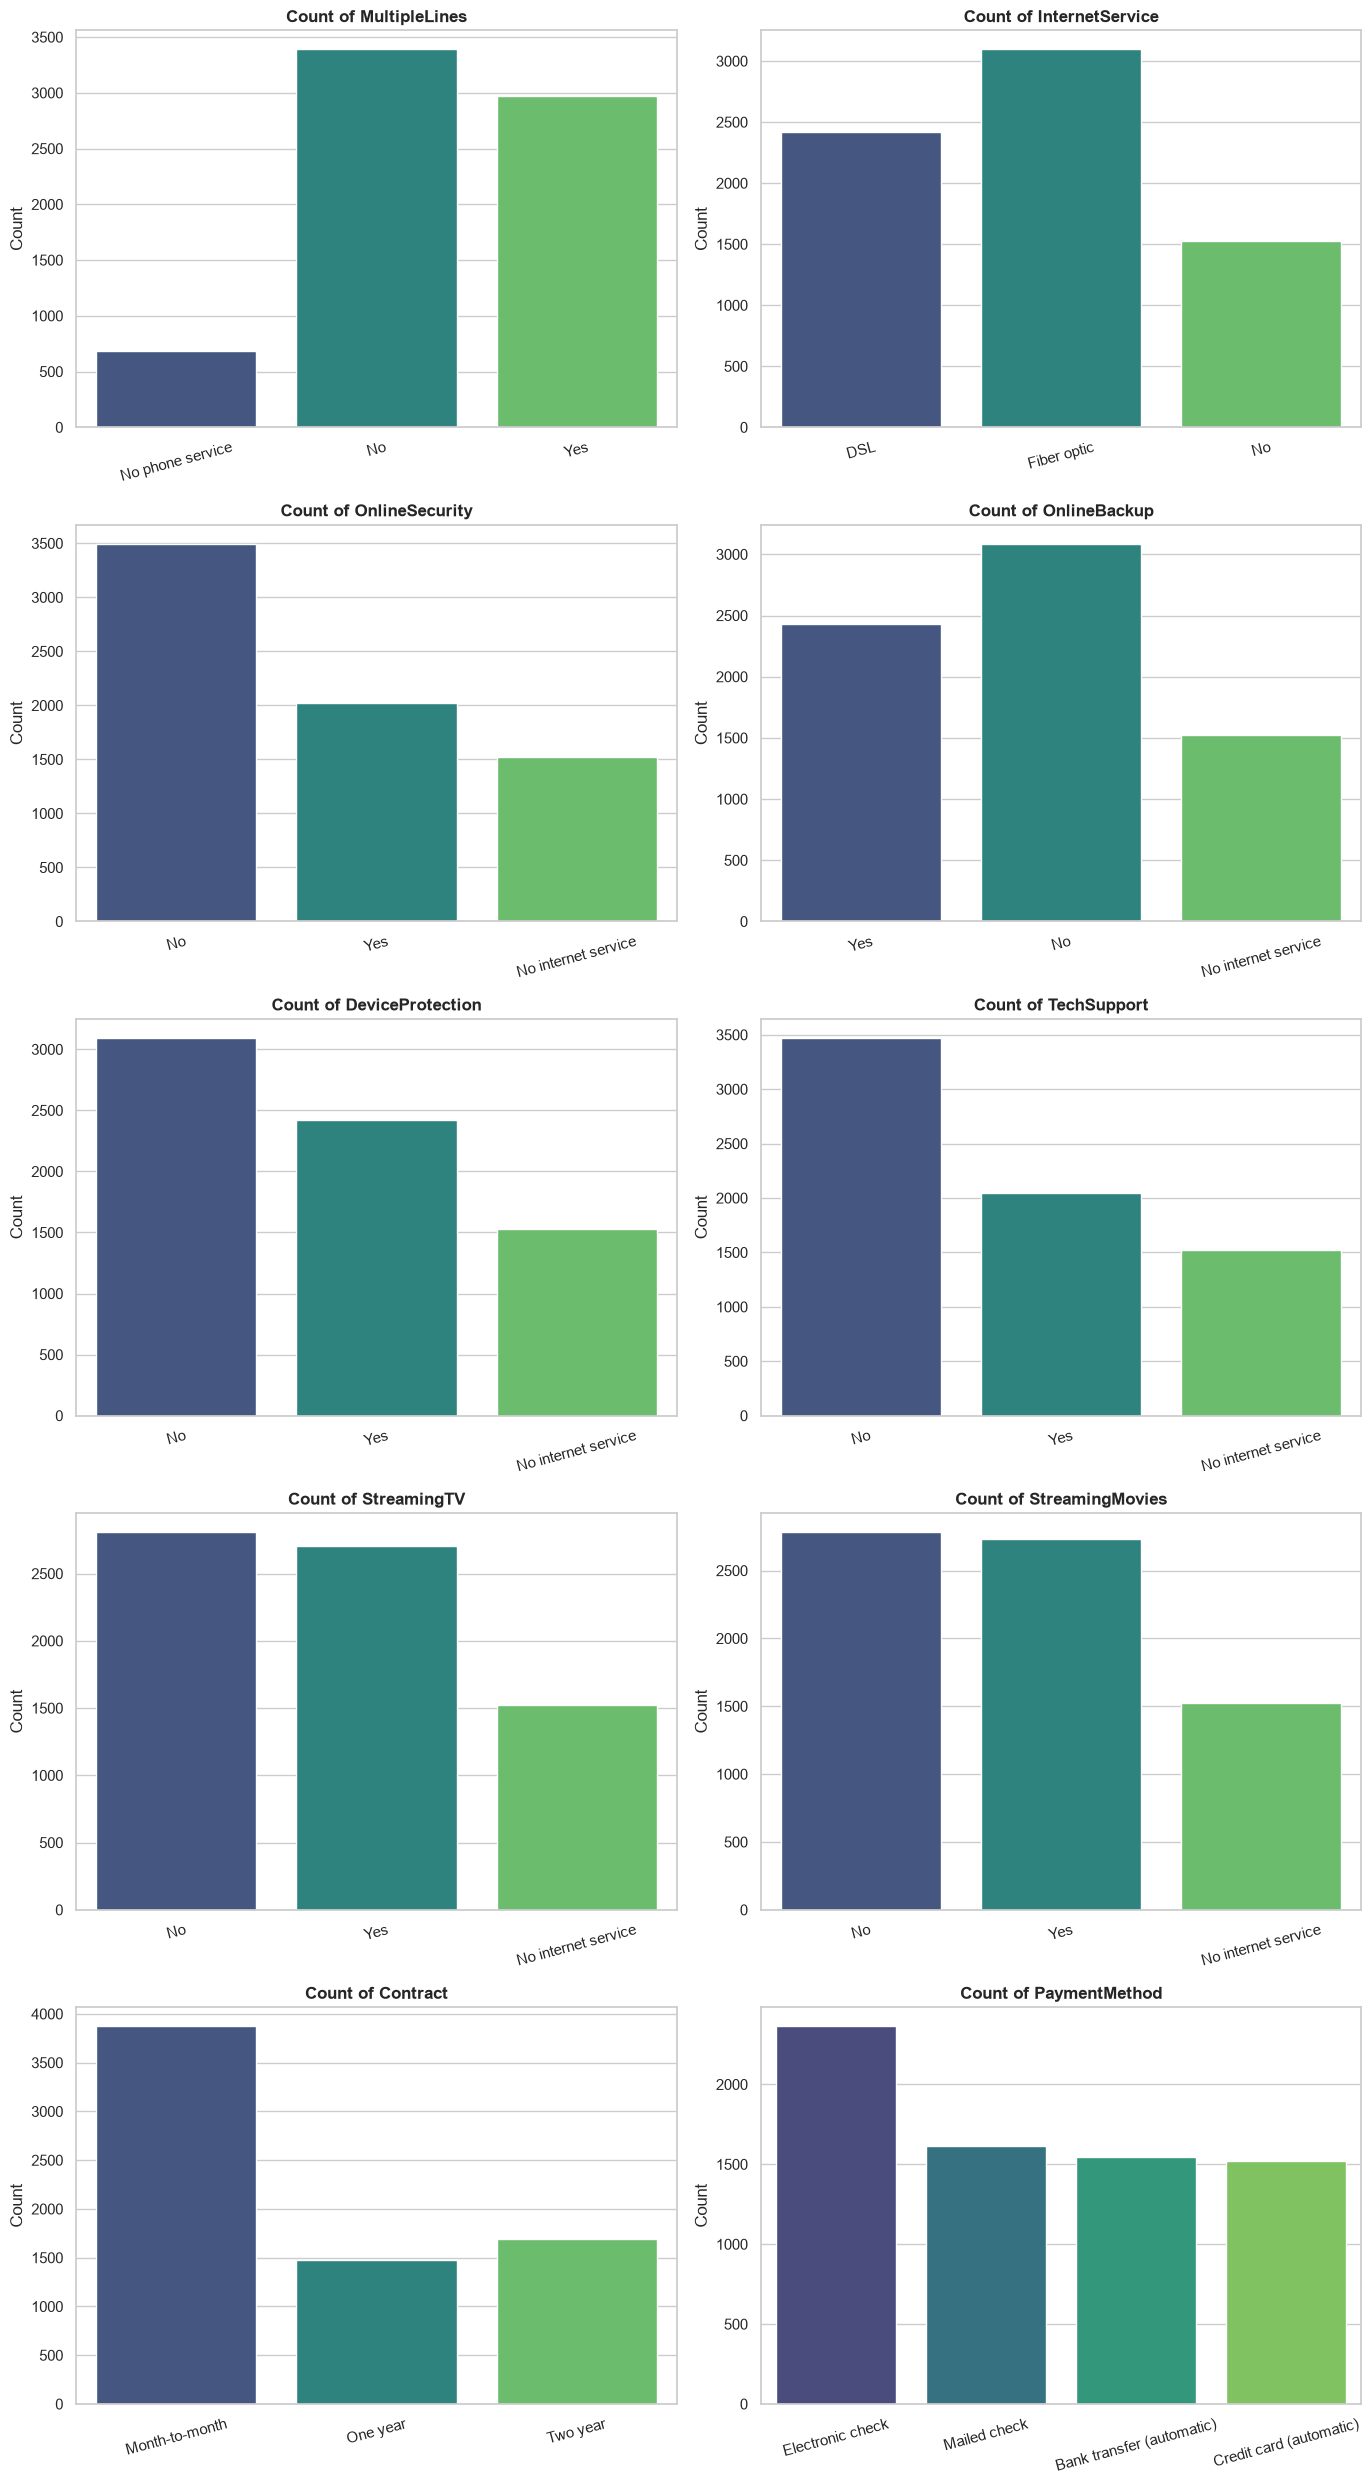

In [12]:


# DISCRETE VARIABLES: BAR CHARTS 
print("\n--- DISCRETE / MULTI-CLASS VARIABLES ---")
fig, axes = plt.subplots(nrows=math.ceil(len(discrete_vars)/2), ncols=2, figsize=(14, 5 * math.ceil(len(discrete_vars)/2)))
axes = axes.flatten()

for i, col in enumerate(discrete_vars):
    sns.countplot(data=df_viz, x=col, ax=axes[i], hue=col, legend=False, palette='viridis')
    axes[i].set_title(f'Count of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

for j in range(i + 1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()

The categorical variables reveal distinct behavioral segments. We observe a balanced split in MultipleLines, with a minority lacking phone service entirely. Regarding internet connectivity, Fiber Optic emerges as the preferred service, followed by DSL, with a significant segment of customers opting out of internet services.

A recurring pattern appears in OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport: a large majority of customers do not utilize these additional security and support services. Furthermore, StreamingTV and StreamingMovies show a near-even split among those with internet access.

Most importantly, the Contract distribution shows a clear preference for month-to-month billing, while PaymentMethod is dominated by electronic checks.

These patterns suggest an interesting segmentation between those who contract internet services and those who do not. We will now proceed to verify if the Internet Users have higher Churn Rate than those who are not Internet Users, using non-parametric tests, which will allow us to effectively segment our dataset and uncover deeper relationships.

### 2.2 Bivariate Tests and Visualizations  (Target VS Features)

In [13]:

internet_users = df[df['InternetService'] != 'No']
no_internet_users = df[df['InternetService'] == 'No']


comparison = pd.DataFrame({
    'Metric': ['Average Tenure', 'Churn Rate (%)', 'Count'],
    'Internet Users': [
        internet_users['tenure'].mean(),
        (internet_users['Churn'] == 'Yes').mean() * 100,
        len(internet_users)
    ],
    'No Internet Users': [
        no_internet_users['tenure'].mean(),
        (no_internet_users['Churn'] == 'Yes').mean() * 100,
        len(no_internet_users)
    ]
})

print("--- SEGMENT COMPARISON: INTERNET VS NON-INTERNET ---")
display(comparison)

--- SEGMENT COMPARISON: INTERNET VS NON-INTERNET ---


,Metric,Internet Users,No Internet Users
0,Average Tenure,32.875657,30.547182
1,Churn Rate (%),31.828893,7.404980
2,Count,5517.000000,1526.000000


To statistically validate the differences observed between internet-enabled and non-internet customer segments, we will conduct hypothesis testing. We will apply the Mann-Whitney U Test to assess differences in the continuous variable tenure and the Chi-Square Test to evaluate the dependency between internet services and the Churn rate. This approach allows us to confirm whether these observed disparities are statistically significant or merely due to random chance.

In [14]:
# TEST FOR TENURE (Mann-Whitney U) 
stat_u, p_u = mannwhitneyu(internet_users['tenure'], no_internet_users['tenure'])

print(f"--- TENURE DIFFERENCE (Mann-Whitney U Test) ---")
print(f"P-value: {p_u:.4e}")
if p_u < 0.05:
    print("Conclusion: The difference in tenure between groups is statistically significant.\n")
else:
    print("Conclusion: There is no statistically significant difference in tenure.\n")

# TEST FOR CHURN (Chi-square) 
# Create a contingency table
contingency_table = pd.crosstab(df['InternetService'] != 'No', df['Churn'])

stat_chi, p_chi, dof, expected = chi2_contingency(contingency_table)

print(f"--- CHURN RATE DIFFERENCE (Chi-square Test) ---")
print(f"P-value: {p_chi:.4e}")
if p_chi < 0.05:
    print("Conclusion: The difference in churn rates between groups is statistically significant.")
else:
    print("Conclusion: There is no statistically significant difference in churn rates.")

--- TENURE DIFFERENCE (Mann-Whitney U Test) ---
P-value: 6.5599e-04
Conclusion: The difference in tenure between groups is statistically significant.

--- CHURN RATE DIFFERENCE (Chi-square Test) ---
P-value: 2.9203e-81
Conclusion: The difference in churn rates between groups is statistically significant.


In fact, these results provide strong evidence to confirm that both Churn rates and tenure are deeply dependent on whether a customer uses internet services. Consequently, our segmentation approach is not just a visual preference but a statistical necessity to accurately understand customer behavior.

--- CATEGORICAL VARIABLES VS CHURN ---


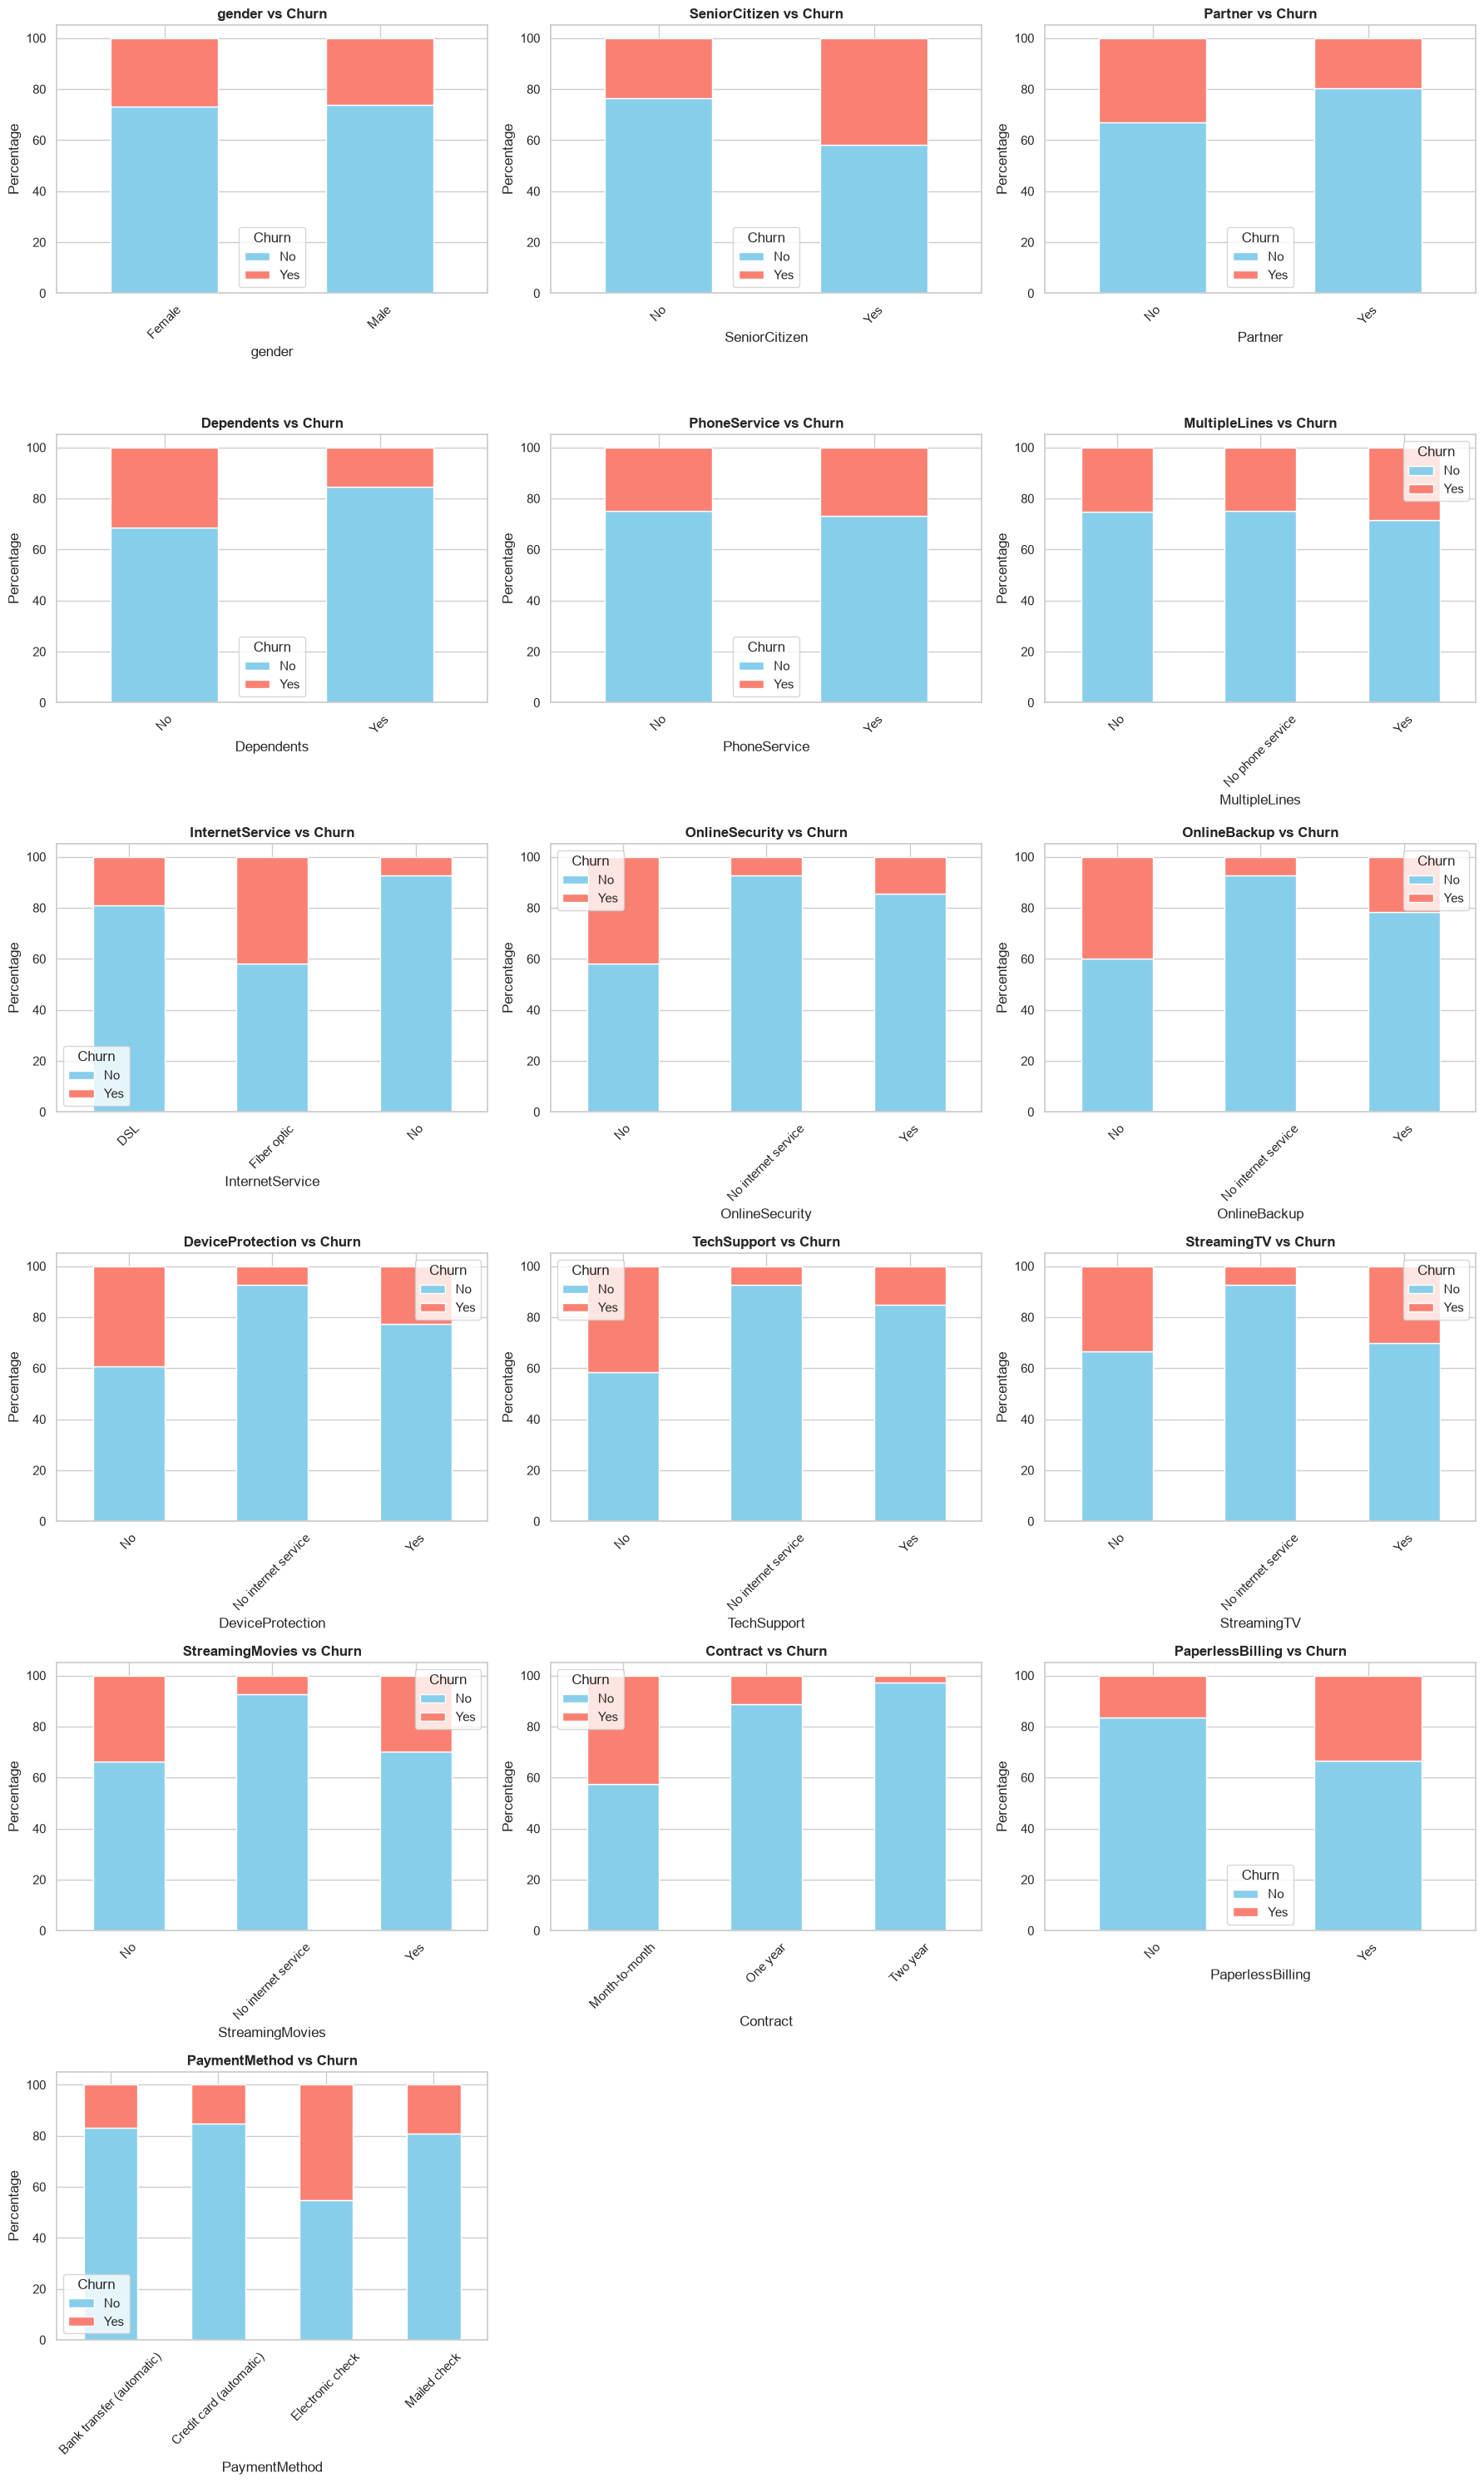

In [15]:


# 1. Aseguramos que TotalCharges sea numérico (limpiando posibles errores)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Aseguramos que SeniorCitizen sea tratado como categoría
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')

# 3. Definimos las listas de forma explícita para evitar errores de adivinación
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = [col for col in df.columns if col not in num_features and col not in ['customerID', 'Churn']]



target = 'Churn'

# --- A. CATEGORICAL VS TARGET ---
print("--- CATEGORICAL VARIABLES VS CHURN ---")
rows_cat = math.ceil(len(cat_features) / 3)

fig, axes = plt.subplots(rows_cat, 3, figsize=(18, 5 * rows_cat))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # crosstab + plot es la forma más limpia de ver % de Churn
    crosstab = pd.crosstab(df[col], df[target], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, ax=axes[i], color=['skyblue', 'salmon'])
    axes[i].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Percentage')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()


After analyzing the variables against the Churn target, we can draw the following conclusions regarding customer behavior:

1. Demographic and Family Profile

Age: Senior Citizens exhibit a significantly higher churn rate compared to younger customers.

Family status: Customers without partners and those without dependents are more likely to churn, suggesting that these profiles may have fewer ties to the company.

2. Services

Connectivity: Fiber optic service correlates with higher churn rates compared to DSL. However, it is crucial to note that customers without internet service are the most loyal, showing negligible churn rates.

Value-added services: There is a clear pattern: customers who do not subscribe to security, backup, device protection, or technical support services are more prone to leave. These services act as a "lock-in" factor, enhancing customer retention.

Streaming: While there is a slight tendency for non-subscribers to churn more, the impact is less significant than that of security or technical support services.

3. Contract and Billing (Critical Drivers)

Contract type: This is the most powerful predictor of churn. There is a strong inverse relationship between contract duration and attrition. Month-to-month customers demonstrate a much higher churn rate compared to those on annual or two-year contracts.

Payment and Billing: Paperless billing is associated with higher churn. Regarding payment methods, the Electronic check stands out as a clear indicator of high turnover, showing a significantly higher attrition rate compared to other payment options.

To provide empirical rigor to our visual observations, we will perform hypothesis testing on the most influential features. By applying Chi-square tests for categorical features and Mann-Whitney U tests for continuous variables, we confirm if the identified drivers of churn have statistically significant associations with the target variable (p < 0.05). This will validate our future selection of features for the predictive modeling phase.

In [16]:


# 1. Convertir todas las columnas numéricas a float, convirtiendo errores a NaN
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Imputar o eliminar los nulos de 'TotalCharges' (que son los que suelen dar guerra)
# Aquí optamos por rellenar con 0 para no perder filas, o dropna() si prefieres
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 3. Asegurar que las columnas categóricas no sean confundidas con numéricas
# Si tienes columnas '0' y '1' que son categorías (como SeniorCitizen), FUÉRZALAS a object
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')

# 4. Verificación final de tipos
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen        object
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [17]:


# 1. Limpieza y tipado forzoso
# Aseguramos que las numéricas sean float y las demás object
num_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_vars:
    # Convertimos a numérico y forzamos nulos a 0 antes de cualquier otra operación
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

# Convertimos explícitamente todo lo que no es numérico a tipo 'category' o 'object'
# Esto evita que VS Code se confunda con columnas que parecen numéricas pero son categorías
for col in df.columns:
    if col not in num_vars and col != 'Churn':
        df[col] = df[col].astype('object')

# 2. Función blindada contra errores de diagnóstico
def perform_comprehensive_statistical_tests(df, target='Churn', alpha=0.05):
    results = []
    num_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']
    features = [col for col in df.columns if col not in [target, 'customerID']]
    
    for var in features:
        if var in num_vars:
            # Filtramos nulos/infinitos explícitamente antes del test
            data = df[var].replace([np.inf, -np.inf], np.nan).dropna()
            g1 = df.loc[df[target] == 'Yes', var].dropna()
            g0 = df.loc[df[target] == 'No', var].dropna()
            
            if len(g1) > 0 and len(g0) > 0:
                _, p = mannwhitneyu(g1, g0)
                test_name = 'Mann-Whitney U'
            else:
                p = 1.0
                test_name = 'Mann-Whitney U (No data)'
        else:
            contingency = pd.crosstab(df[var], df[target])
            _, p, _, _ = chi2_contingency(contingency)
            test_name = 'Chi-square'
            
        results.append({'Variable': var, 'Test': test_name, 'P-value': p})
    
    results_df = pd.DataFrame(results)
    significant = results_df[results_df['P-value'] < alpha]['Variable'].tolist()
    not_significant = results_df[results_df['P-value'] >= alpha]['Variable'].tolist()
    
    return results_df, significant, not_significant

# 3. Ejecución
stats_df, sig_vars, non_sig_vars = perform_comprehensive_statistical_tests(df)

# 4. Mostrar resultados
display(stats_df.sort_values(by='P-value'))

print(f"\n--- SIGNIFICANT VARIABLES (p < 0.05) ---")
print(", ".join(sig_vars))
print(f"\n--- NOT SIGNIFICANT VARIABLES (p >= 0.05) ---")
print(", ".join(non_sig_vars) if non_sig_vars else "None")

,Variable,Test,P-value
14,Contract,Chi-square,5.863038e-258
4,tenure,Mann-Whitney U,2.419636e-208
8,OnlineSecurity,Chi-square,2.661150e-185
11,TechSupport,Chi-square,1.443084e-180
7,InternetService,Chi-square,9.571788e-160
16,PaymentMethod,Chi-square,3.682355e-140
9,OnlineBackup,Chi-square,2.079759e-131
10,DeviceProtection,Chi-square,5.505219e-122
18,TotalCharges,Mann-Whitney U,5.685034e-83
13,StreamingMovies,Chi-square,2.667757e-82



--- SIGNIFICANT VARIABLES (p < 0.05) ---
SeniorCitizen, Partner, Dependents, tenure, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges

--- NOT SIGNIFICANT VARIABLES (p >= 0.05) ---
gender, PhoneService


The statistical analysis confirms that almost all features have a significant impact on customer churn, with the notable exceptions of gender and PhoneService, which show no statistically significant relationship. Consequently, these findings validate our focus on service-related and contractual factors as the primary drivers of customer attrition.


Having statistically validated the significance of our features, we now proceed to explore the underlying relationships between the continuous variables and the target. By employing pairplots for continuous variables and correlation mapping for categorical associations, we aim to uncover the specific dynamics and interaction patterns that define the churn behavior, providing a deeper understanding of our customer segments.


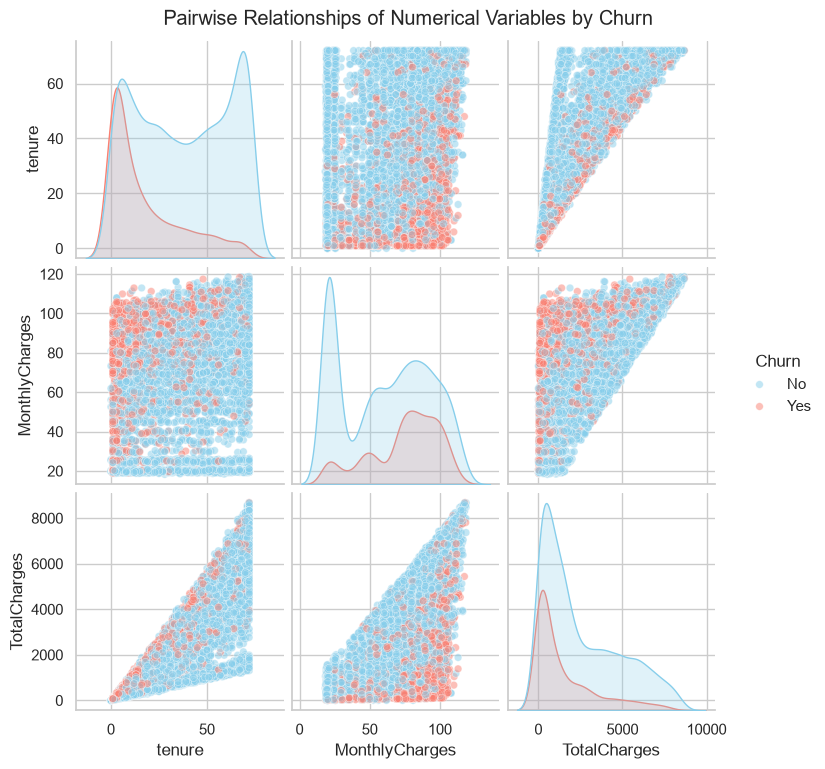

In [18]:
# Automatización: Identificar solo variables numéricas
num_features = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col != 'Churn']

# Generar el pairplot solo con las numéricas detectadas automáticamente
sns.pairplot(df, hue='Churn', vars=num_features, 
             palette={'No': 'skyblue', 'Yes': 'salmon'}, 
             plot_kws={'alpha': 0.5, 's': 30})

plt.suptitle('Pairwise Relationships of Numerical Variables by Churn', y=1.02)
plt.show()

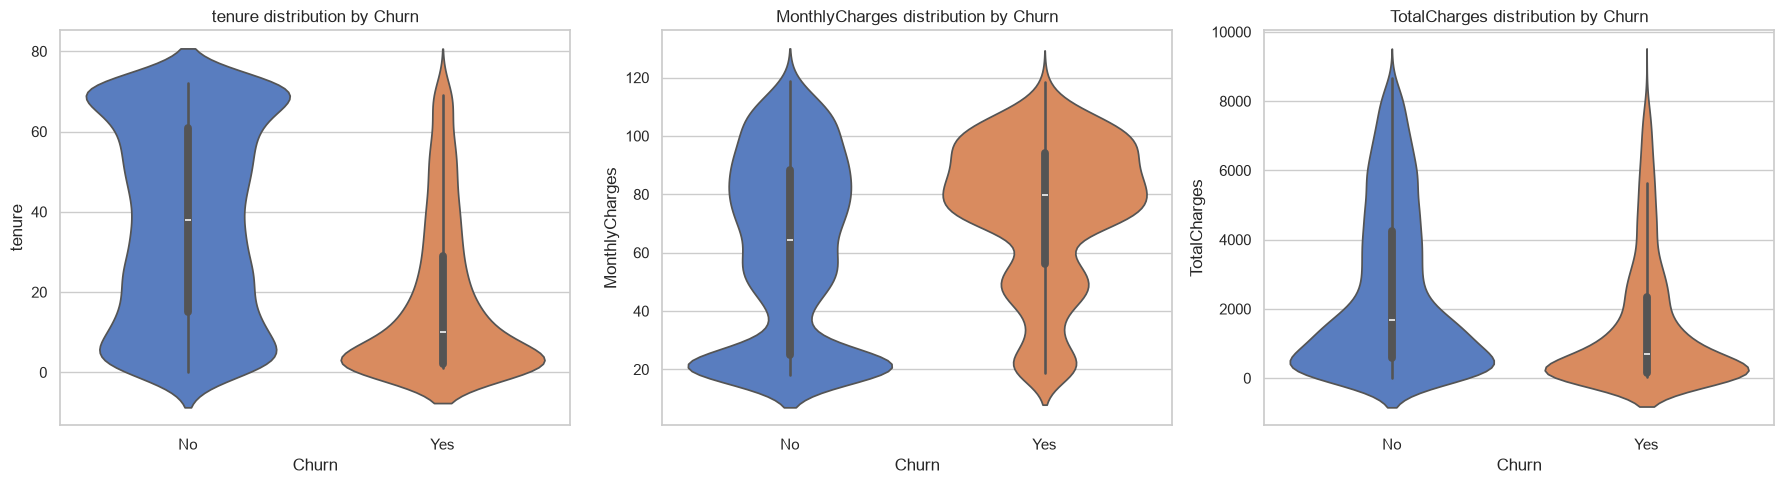

In [19]:






# Crear un grid de violin plots enfrentados al Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(num_features):
    # Añadimos hue='Churn' y legend=False para silenciar el warning y mejorar el estilo
    sns.violinplot(data=df, x='Churn', y=var, hue='Churn', ax=axes[i], palette='muted', legend=False)
    axes[i].set_title(f'{var} distribution by Churn')

plt.tight_layout()
plt.show()

By integrating pairwise relationships and conditional distributions, we have identified key behavioral patterns regarding customer lifetime value and churn risk:

Initial Tenure Vulnerability: Both pairplot densities and violin plots indicate a high concentration of churn events within the first few months of the relationship. This confirms that the risk of attrition is highest during the early stages of the customer lifecycle, highlighting the critical importance of the onboarding process for retention.

High-Value Segment Instability: The MonthlyCharges distribution reveals a distinct duality: while basic-service customers exhibit high retention, churn rates increase significantly among premium plans. Specifically, we identify a high-risk segment consisting of new customers with high monthly charges, who demonstrate the lowest stability levels.

TotalCharges Redundancy: Pairwise analysis confirms that TotalCharges functions primarily as a dependent variable of tenure. Because customers who churn early naturally accumulate lower total billing amounts, this variable provides limited independent predictive power. This will be further evaluated using a Spearman correlation matrix to identify and eliminate potential feature redundancy in our modeling phase.

### 2.3 Multicollineality and redundance between features

Having explored the individual impact of features on customer churn, we now proceed to a deeper assessment of feature interdependence. By analyzing numerical correlations (Spearman) and categorical associations (Cramér's V), we aim to identify potential multicollinearity and redundant variables. This quantitative validation is a critical diagnostic step to mitigate feature redundancy and ensure our feature set is streamlined. By systematically flagging variables with high correlation coefficients, we will be able to treat multicollinearity appropriately, ensuring that our final dataset is optimized for predictive modeling without introducing noise from redundant predictors.

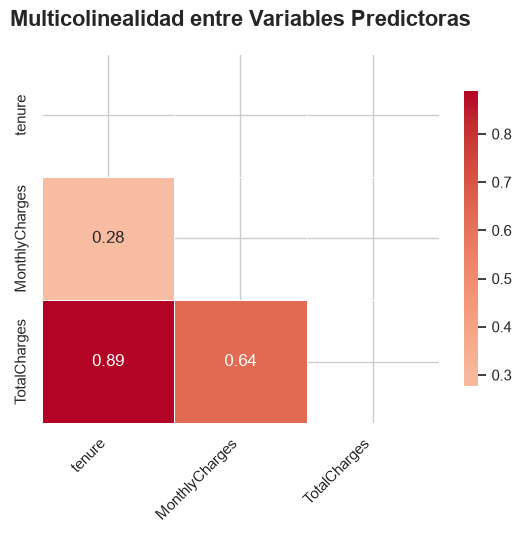


Variables with higher absolute correlation than 0.8:

TotalCharges  tenure    0.889696
dtype: float64


In [20]:



corr_matrix_spearman = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(method='spearman')

# Máscara triangular
mask = np.triu(np.ones_like(corr_matrix_spearman, dtype=bool))

# Heatmap

sns.heatmap(
    corr_matrix_spearman,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title(
    'Multicolinealidad entre Variables Predictoras',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.xticks(rotation=45, ha='right')
plt.show()


corr_pairs = corr_matrix_spearman.abs().unstack()

# Ordenar correlaciones
corr_pairs = corr_pairs.sort_values(ascending=False)

# Eliminar autocorrelaciones (=1)
corr_pairs = corr_pairs[corr_pairs < 1]

# Eliminar duplicados
corr_pairs = corr_pairs.drop_duplicates()

# Filtrar correlaciones altas
umbral = 0.80

high_corr = corr_pairs[corr_pairs > umbral]

print(f"\nVariables with higher absolute correlation than {umbral}:\n")
print(high_corr)


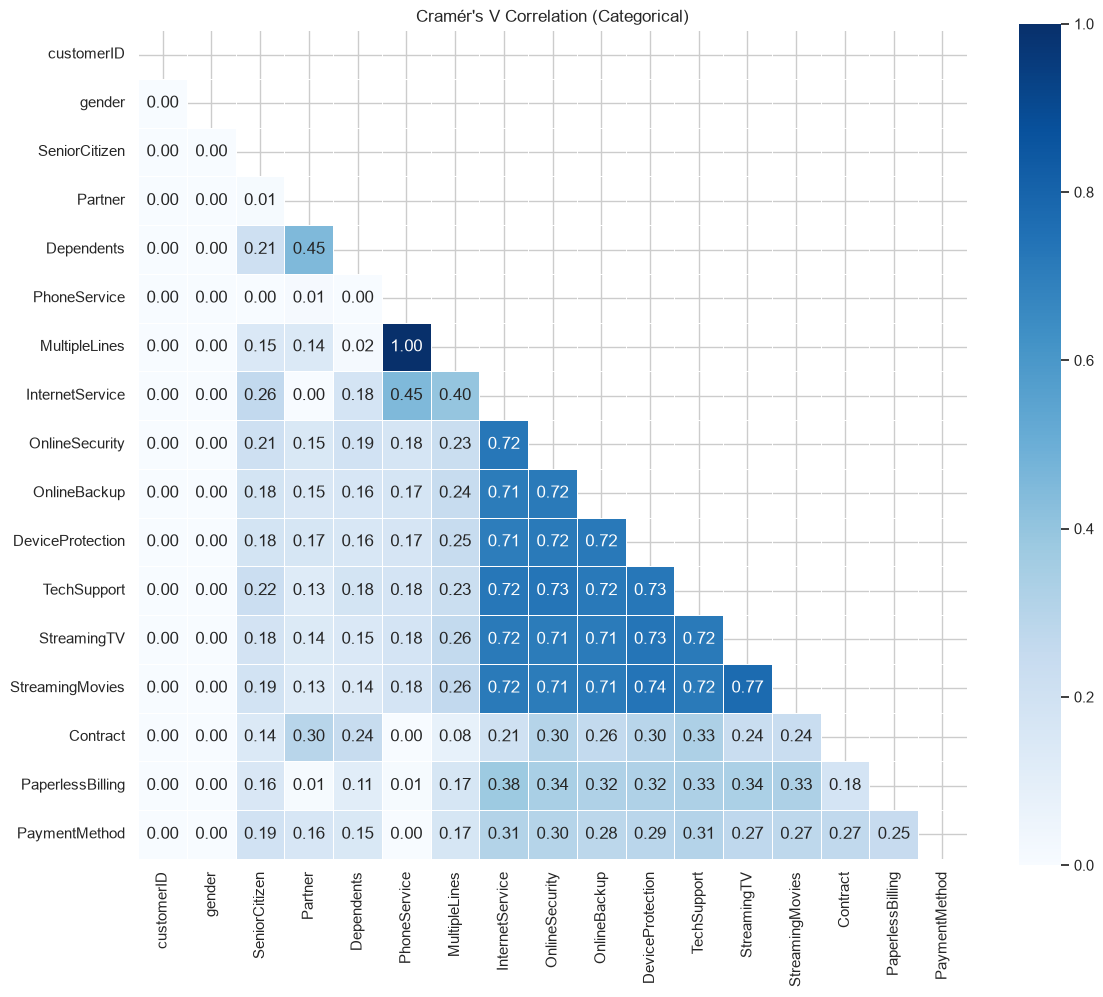

In [21]:






# 1. DEFINICIÓN DE LA FUNCIÓN (Primero definimos la función)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    # chi2_contingency devuelve una tupla, el valor chi2 es el primero
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Ajuste de corrección para evitar sesgos en tablas pequeñas
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    res = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1))) if min((kcorr-1), (rcorr-1)) > 0 else 0
    return res

# 2. PREPARACIÓN DE DATOS (Seleccionamos categóricas y limpiamos)
# Aseguramos que todas sean tipo string para evitar errores en crosstab
cat_cols = [col for col in df.select_dtypes(include=['object', 'category', 'string']).columns if col != 'Churn']
cat_cols = [col for col in cat_cols if df[col].nunique() > 1] 

for col in cat_cols:
    df[col] = df[col].astype(str)

# 3. CREACIÓN DE LA MATRIZ
corr_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1 in cat_cols:
    for col2 in cat_cols:
        corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# 4. PLOT DEL HEATMAP
plt.figure(figsize=(12, 10))

# Máscara para ocultar triángulo superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix.astype(float), 
            mask=mask, 
            annot=True, 
            cmap='Blues', 
            fmt=".2f", 
            vmin=0, 
            vmax=1, 
            square=True, 
            linewidths=.5)

plt.title('Cramér\'s V Correlation (Categorical)')
plt.tight_layout()
plt.show()

The PhoneService variable proves to be redundant, as MultipleLines already categorizes the availability of phone service (including the 'No phone service' option). Likewise, we observe a compact cluster with correlations around 0.70 among the internet service features (OnlineSecurity, OnlineBackup, etc.). This correlation is logical, given that access to these additional services is conditional upon having an active internet service. This high interdependence suggests a structural redundancy that must be addressed to optimize the performance of the predictive model.

1. EDA Final Summary: Key Findings

The Exploratory Data Analysis has provided a comprehensive overview of the customer base, highlighting critical drivers of churn and data structural insights. Our key takeaways are:

Behavioral Drivers: Customer churn is most prevalent among new clients with high monthly charges and short tenure. These segments represent the highest risk, emphasizing the need for targeted onboarding and retention strategies.

Contractual Impact: The type of contract is the most significant categorical predictor of churn, with month-to-month contracts showing a clear propensity for attrition compared to longer-term commitments.

Data Redundancy: Through collinearity and association mapping, we have identified structural redundancies: TotalCharges is largely a function of tenure, and multiple service-related features (PhoneService, OnlineSecurity, OnlineBackup, etc.) exhibit high interdependencies.



2. Data Pre-processing Measures

To ensure the predictive model is robust, efficient, and free from collinearity bias, the following actions will be implemented before training:

Feature Removal:

- customerID: Dropped as it is a unique identifier with no predictive value.

- TotalCharges: Removed to mitigate high multicollinearity with tenure.

- PhoneService: Excluded due to its perfect correlation with MultipleLines.




## 3. Feature Engineering

To optimize model performance, we will evaluate two distinct feature sets through an iterative benchmarking process. This approach allows us to quantify the impact of dimensionality reduction versus information granularity on predictive accuracy.

Experimental Strategy: We will conduct a comparative analysis between two model versions:

 - Baseline Set: Retains all individual service features to maximize information granularity for the learning algorithm.

- Aggregated Set: Consolidates the six internet-related features (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) into a single index: TotalAdditionalServices. While InternetService is preserved as a key indicator of connectivity type, the aggregation aims to mitigate structural redundancy and multicollinearity within the service bundle.

Data Transformation:

- Encoding: To align with Machine Learning requirements, we will convert categorical variables into numerical formats. Specifically, we will utilize One-Hot Encoding for nominal features (e.g., PaymentMethod, Gender) to avoid implying a false sense of order, and Label Encoding (or ordinal encoding) for features with an inherent hierarchy (e.g., Contract duration).

To prevent the 'dummy variable trap' and ensure matrix invertibility for linear-based models, we will implement the drop_first=True approach, effectively reducing multicollinearity. For tree-based ensemble methods, which are inherently robust to redundant binary features, we will assess the performance impact of retaining the full categorical set versus the reduced version.

## 4. MODEL SELECTION AND ITERATIVE BENCHMARKING (FROM SCRATCH)

In [ ]:

%%time


cols_to_drop = ['customerID', 'TotalCharges', 'PhoneService']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])


X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# ==============================================================================
# 4.2. **CUSTOM TRANSFORMER: Service Aggregator**
# ==============================================================================
class ServiceAggregator(BaseEstimator, TransformerMixin):
    def __init__(self, drop_originals=True):
        self.drop_originals = drop_originals
        self.service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                             'TechSupport', 'StreamingTV', 'StreamingMovies']
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        # How many "Yes" are there in the extra services
        X_copy['TotalAdditionalServices'] = X_copy[self.service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)
        
        # Drop or keep the original service columns based on the strategy
        if self.drop_originals:
            X_copy = X_copy.drop(columns=self.service_cols)
            
        return X_copy

# ==============================================================================
# 4.3. EXPERIMENT SETTINGS (NESTED CV)
# ==============================================================================

estrategias_fe = {
    'Variables Separadas (Granular)': False, # Keeps the 6 separate service variables
    'Variables Agrupadas (Aggregated)': True # Drops the 6 service variables, keeps only the total
}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

resultados_globales = []



# ==============================================================================
# 4.4. MAIN EVALUATION LOOP 
# ==============================================================================
for nombre_estrategia, drop_flag in estrategias_fe.items():
    print(f"{'='*60}")
    print(f"🧪 TRAINING PHASE: {nombre_estrategia.upper()}")
    print(f"{'='*60}")
    
    # --- A) DINAMIC DEFINITION OF THE PREPROCESSOR ---
    # If drop_flag is True, we drop the original service columns and only keep the aggregated one. Otherwise, we keep all.
    service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    base_cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']
    
    cat_cols = base_cat_cols if drop_flag else base_cat_cols + service_cols
    num_cols = ['tenure', 'MonthlyCharges', 'TotalAdditionalServices']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
        ], 
        remainder='drop'
    )

    # --- B) MODELS DICTIONARY WITH HYPERPARAMETER TUNING ---
    models = {
        'Logistic Regression (Baseline)': {
            'pipeline': Pipeline([
                ('agrupacion', ServiceAggregator(drop_originals=drop_flag)),
                ('preprocess', preprocessor),
                ('model', LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced'))
            ]),
            'param_grid': {
                'model__C': [0.01, 0.1, 1, 10, 100],
                'model__penalty': ['l1', 'l2'],
                'model__solver': ['liblinear']
            }
        },
        'Random Forest': {
            'pipeline': Pipeline([
                ('agrupacion', ServiceAggregator(drop_originals=drop_flag)),
                ('preprocess', preprocessor),
                ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
            ]),
            'param_grid': {
                'model__n_estimators': [100, 300, 500],
                'model__max_depth': [5, 10, 15, None],
                'model__min_samples_leaf': [1, 2, 4]
            }
        },
        'XGBoost': {
            'pipeline': Pipeline([
                ('agrupacion', ServiceAggregator(drop_originals=drop_flag)),
                ('preprocess', preprocessor),
                ('model', XGBClassifier(random_state=42, objective='binary:logistic', eval_metric='logloss', scale_pos_weight=3))
            ]),
            'param_grid': {
                'model__n_estimators': [100, 300],
                'model__max_depth': [3, 5, 7],
                'model__learning_rate': [0.01, 0.05, 0.1]
            }
        },
        'LightGBM': {
            'pipeline': Pipeline([
                ('agrupacion', ServiceAggregator(drop_originals=drop_flag)),
                ('preprocess', preprocessor),
                ('model', LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1))
            ]),
            'param_grid': {
                'model__n_estimators': [100, 300],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__num_leaves': [31, 50, 100],
                'model__max_depth': [-1, 5, 10]
            }
        },
        'SVM': {
            'pipeline': Pipeline([
                ('agrupacion', ServiceAggregator(drop_originals=drop_flag)),
                ('preprocess', preprocessor),
                ('model', SVC(probability=True, random_state=42, class_weight='balanced'))
            ]),
            'param_grid': {
                'model__C': [0.1, 1, 10],
                'model__kernel': ['rbf'] 
            }
        },
        'KNN': {
            'pipeline': Pipeline([
                ('agrupacion', ServiceAggregator(drop_originals=drop_flag)),
                ('preprocess', preprocessor),
                ('model', KNeighborsClassifier())
            ]),
            'param_grid': {
                'model__n_neighbors': [5, 11, 21],
                'model__weights': ['uniform', 'distance']
            }
        }
    }

    # --- C) TRAINING AND EVALUATION (NESTED CV) ---
    for model_name, model_info in models.items():
        print(f"Training -> {model_name}...")
        
        f1_folds = []
        auc_folds = []
        
        for train_idx, test_idx in outer_cv.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Hiperparameter tuning with inner CV
            grid = GridSearchCV(
                estimator=model_info['pipeline'],
                param_grid=model_info['param_grid'],
                cv=inner_cv,
                scoring='f1',
                n_jobs=-1 
            )
            grid.fit(X_train, y_train)

            # Predictions and probabilities
            y_pred = grid.predict(X_test)
            y_pred_proba = grid.predict_proba(X_test)[:, 1]

            
            f1_folds.append(f1_score(y_test, y_pred))
            auc_folds.append(roc_auc_score(y_test, y_pred_proba))

        
        n_folds = outer_cv.get_n_splits()
        t_crit = st.t.ppf(0.975, df=n_folds-1)
        
        f1_mean = np.mean(f1_folds)
        f1_margin = t_crit * (np.std(f1_folds, ddof=1) / np.sqrt(n_folds))
        auc_mean = np.mean(auc_folds)
        auc_margin = t_crit * (np.std(auc_folds, ddof=1) / np.sqrt(n_folds))

        resultados_globales.append({
            'Strategy': nombre_estrategia,
            'Model': model_name,
            'F1 Mean': f1_mean,
            '95% CI (F1)': f"[{f1_mean - f1_margin:.4f}, {f1_mean + f1_margin:.4f}]",
            'AUC Mean': auc_mean,
            '95% CI (AUC)': f"[{auc_mean - auc_margin:.4f}, {auc_mean + auc_margin:.4f}]"
        })


# ==============================================================================
# 4.5. VISUAL PRESENTATION OF RESULTS
# ==============================================================================
df_resultados = pd.DataFrame(resultados_globales)
df_resultados = df_resultados.sort_values(by=['Strategy', 'F1 Mean'], ascending=[False, False]).reset_index(drop=True)

# Easier visualization with a gradient background for the F1 and AUC columns
cm = sns.light_palette("blue", as_cmap=True)
tabla_estilizada = df_resultados.style.background_gradient(subset=['F1 Mean', 'AUC Mean'], cmap=cm)\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])

display(tabla_estilizada)

🧪 TRAINING PHASE: VARIABLES SEPARADAS (GRANULAR)
Entrenando -> Logistic Regression (Baseline)...
Entrenando -> Random Forest...
Entrenando -> XGBoost...
Entrenando -> LightGBM...
Entrenando -> SVM...
Entrenando -> KNN...
🧪 TRAINING PHASE: VARIABLES AGRUPADAS (AGGREGATED)
Entrenando -> Logistic Regression (Baseline)...
Entrenando -> Random Forest...
Entrenando -> XGBoost...
Entrenando -> LightGBM...
Entrenando -> SVM...
Entrenando -> KNN...


,Strategy,Model,F1 Mean,95% CI (F1),AUC Mean,95% CI (AUC)
0,Variables Separadas (Granular),LightGBM,0.628410,"[0.6136, 0.6432]",0.842090,"[0.8278, 0.8563]"
1,Variables Separadas (Granular),XGBoost,0.627668,"[0.6069, 0.6484]",0.845562,"[0.8281, 0.8630]"
2,Variables Separadas (Granular),Random Forest,0.626910,"[0.6087, 0.6451]",0.841986,"[0.8262, 0.8578]"
3,Variables Separadas (Granular),Logistic Regression (Baseline),0.626883,"[0.6092, 0.6446]",0.843092,"[0.8244, 0.8618]"
4,Variables Separadas (Granular),SVM,0.620864,"[0.6028, 0.6389]",0.830258,"[0.8115, 0.8490]"
5,Variables Separadas (Granular),KNN,0.583275,"[0.5509, 0.6156]",0.826558,"[0.8042, 0.8489]"
6,Variables Agrupadas (Aggregated),LightGBM,0.626165,"[0.6130, 0.6393]",0.840177,"[0.8259, 0.8545]"
7,Variables Agrupadas (Aggregated),Random Forest,0.625852,"[0.6020, 0.6497]",0.840921,"[0.8241, 0.8577]"
8,Variables Agrupadas (Aggregated),Logistic Regression (Baseline),0.625605,"[0.6042, 0.6471]",0.841231,"[0.8214, 0.8611]"
9,Variables Agrupadas (Aggregated),XGBoost,0.624433,"[0.6047, 0.6442]",0.842263,"[0.8246, 0.8599]"


CPU times: total: 4min 38s
Wall time: 9min 34s


The iterative benchmarking process yielded highly insightful results regarding both our feature engineering strategy and model selection:

Information Granularity Prevails: The hypothesis that feature aggregation would improve generalization was empirically disproven. All top-performing models achieved higher F1 and ROC-AUC scores using the Granular strategy (retaining individual internet service features). This indicates that the specific type of service provides nuanced predictive signals that are lost when consolidated into a single numerical index.

The Top Performer and the Statistical Tie: While LightGBM initially emerged at the top of the leaderboard with the highest mean F1-Score (0.6284), benefiting from its ability to handle complex tabular distributions and class imbalances natively, the performance margins separating it from the next three models are virtually negligible. Consequently, before crowning a definitive winner for production, we must conduct a statistical significance test to determine if this constitutes a technical tie.

In [23]:
# ==============================================================================
# 4.6. STATISTICAL SIGNIFICANCE TESTING BETWEEN STRATEGIES (TOP 4 MODELS)
# ==============================================================================



cols_to_drop = ['customerID', 'TotalCharges', 'PhoneService']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn'].map({'Yes': 1, 'No': 0})


class ServiceAggregator(BaseEstimator, TransformerMixin):
    def __init__(self, drop_originals=True):
        self.drop_originals = drop_originals
        self.service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                             'TechSupport', 'StreamingTV', 'StreamingMovies']
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy['TotalAdditionalServices'] = X_copy[self.service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)
        if self.drop_originals:
            X_copy = X_copy.drop(columns=self.service_cols)
        return X_copy


service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
base_cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']
cat_cols = base_cat_cols + service_cols

preprocessor_granular = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['tenure', 'MonthlyCharges', 'TotalAdditionalServices']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ], remainder='drop'
)


print("CONFIGURING TOP MODELS FOR STATISTICAL TESTING...\n")
modelos_top = {
    'LightGBM': Pipeline([
        ('agrupacion', ServiceAggregator(drop_originals=False)),
        ('preprocess', preprocessor_granular),
        ('model', LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1))
    ]),
    'XGBoost': Pipeline([
        ('agrupacion', ServiceAggregator(drop_originals=False)),
        ('preprocess', preprocessor_granular),
        ('model', XGBClassifier(random_state=42, objective='binary:logistic', eval_metric='logloss', scale_pos_weight=3))
    ]),
    'Random Forest': Pipeline([
        ('agrupacion', ServiceAggregator(drop_originals=False)),
        ('preprocess', preprocessor_granular),
        ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ]),
    'Logistic Regression': Pipeline([
        ('agrupacion', ServiceAggregator(drop_originals=False)),
        ('preprocess', preprocessor_granular),
        ('model', LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced'))
    ])
}

param_grids = {
    'LightGBM': {'model__n_estimators': [100, 300], 'model__learning_rate': [0.05, 0.1]},
    'XGBoost': {'model__n_estimators': [100, 300], 'model__learning_rate': [0.05, 0.1]},
    'Random Forest': {'model__n_estimators': [100, 300], 'model__max_depth': [5, 10]},
    'Logistic Regression': {'model__C': [0.1, 1, 10]}
}

# NESTED CROSS-VALIDATION FOR STATISTICAL SIGNIFICANCE TESTING
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scores_folds = {modelo: [] for modelo in modelos_top.keys()}


for train_idx, test_idx in outer_cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    for nombre, pipeline in modelos_top.items():
        grid = GridSearchCV(pipeline, param_grids[nombre], cv=inner_cv, scoring='f1', n_jobs=-1)
        grid.fit(X_train, y_train)
        score = f1_score(y_test, grid.predict(X_test))
        scores_folds[nombre].append(score)


print(f"{'='*60}")
print("STATISTICAL SIGNIFICANCE TESTING BETWEEN TOP MODELS (CONFIDENCE INTERVALS)\n")
print(f"{'='*60}\n")

campeon = 'LightGBM'
n_folds = outer_cv.get_n_splits()
t_crit = st.t.ppf(0.975, df=n_folds-1)

for rival in ['XGBoost', 'Random Forest', 'Logistic Regression']:
    diferencias = np.array(scores_folds[campeon]) - np.array(scores_folds[rival])
    media_diff = np.mean(diferencias)
    std_diff = np.std(diferencias, ddof=1)
    
    margen_error = t_crit * (std_diff / np.sqrt(n_folds))
    ic_inf = media_diff - margen_error
    ic_sup = media_diff + margen_error
    
    print(f"🆚 {campeon} vs {rival}")
    print(f"   Medium difference (F1): {media_diff:+.4f}")
    print(f"   Interval at 95%: [{ic_inf:+.4f}, {ic_sup:+.4f}]")
    
    if ic_inf <= 0 <= ic_sup:
        print("   ✅ TECNICAL CONCLUSION: No significant difference between models (CI includes 0).")
    else:
        ganador = campeon if media_diff > 0 else rival
        print(f"   ❌ TECNICAL CONCLUSION: Significant difference between models (CI does not include 0).")
    print("-" * 60)

CONFIGURING TOP MODELS FOR STATISTICAL TESTING...

STATISTICAL SIGNIFICANCE TESTING BETWEEN TOP MODELS (CONFIDENCE INTERVALS)


🆚 LightGBM vs XGBoost
   Medium difference (F1): +0.0017
   Interval at 95%: [-0.0094, +0.0128]
   ✅ TECNICAL CONCLUSION: No significant difference between models (CI includes 0).
------------------------------------------------------------
🆚 LightGBM vs Random Forest
   Medium difference (F1): +0.0015
   Interval at 95%: [-0.0109, +0.0138]
   ✅ TECNICAL CONCLUSION: No significant difference between models (CI includes 0).
------------------------------------------------------------
🆚 LightGBM vs Logistic Regression
   Medium difference (F1): -0.0005
   Interval at 95%: [-0.0164, +0.0155]
   ✅ TECNICAL CONCLUSION: No significant difference between models (CI includes 0).
------------------------------------------------------------


The statistical significance analysis (95% CI) confirms a technical tie in the F1-score among the four finalist models (LightGBM, XGBoost, Random Forest, and Logistic Regression).

Given this performance parity, the principle of parsimony and industry best practices dictate prioritizing the simplest solution. Therefore, due to its complete interpretability (white-box model), its high computational and time efficiency, and its ease of deployment in production, the final algorithm selected for this project is Logistic Regression.

Searching for the best 'C' hyperparameter and training the final model with 100% of the data...

The best 'C' hyperparameter found is: 0.1



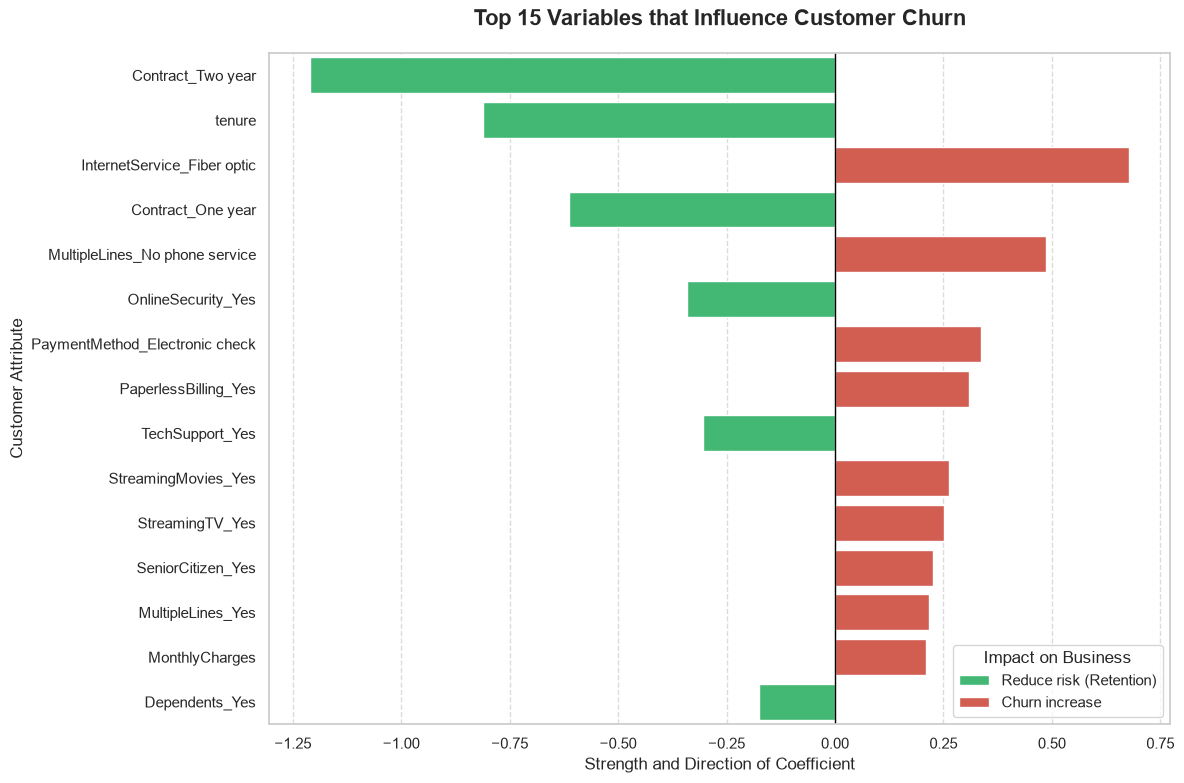

In [24]:

# FINAL MODEL TRAINING WITH BEST HYPERPARAMETER SEARCH



print("Searching for the best 'C' hyperparameter and training the final model with 100% of the data...\n")

# 1.Reconstruct the preprocessor with all features (including the service columns)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
base_cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']
cat_cols = base_cat_cols + service_cols

preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['tenure', 'MonthlyCharges', 'TotalAdditionalServices']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ], remainder='drop'
)

# 2. Pipeline with the ServiceAggregator and Logistic Regression and C as hyperparameter to tune
pipeline_base = Pipeline([
    ('agrupacion', ServiceAggregator(drop_originals=False)), 
    ('preprocess', preprocessor_final),
    ('model', LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced'))
])


param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_final = GridSearchCV(pipeline_base, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_final.fit(X, y)


mejor_modelo = grid_final.best_estimator_
mejor_C = grid_final.best_params_['model__C']


print(f"The best 'C' hyperparameter found is: {mejor_C}\n")




modelo_lr = mejor_modelo.named_steps['model']
preprocesador = mejor_modelo.named_steps['preprocess']


nombres_features = preprocesador.get_feature_names_out()
nombres_limpios = [nombre.replace('num__', '').replace('cat__', '') for nombre in nombres_features]

# Extract the coefficients from the trained Logistic Regression model
coeficientes = modelo_lr.coef_[0]


df_coef = pd.DataFrame({
    'Variable': nombres_limpios,
    'Coeficiente': coeficientes
})

# Absolute impact for sorting
df_coef['Impacto_Absoluto'] = df_coef['Coeficiente'].abs()
df_coef = df_coef.sort_values(by='Impacto_Absoluto', ascending=False).head(15)

# Classify the effect based on the sign of the coefficient
df_coef['Efecto'] = df_coef['Coeficiente'].apply(lambda x: 'Churn increase' if x > 0 else 'Reduce risk (Retention)')




plt.figure(figsize=(12, 8))
barplot = sns.barplot(
    data=df_coef, 
    x='Coeficiente', 
    y='Variable', 
    hue='Efecto',
    palette={'Churn increase': '#e74c3c', 'Reduce risk (Retention)': '#2ecc71'},
    dodge=False
)

plt.title('Top 15 Variables that Influence Customer Churn', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Strength and Direction of Coefficient', fontsize=12)
plt.ylabel('Customer Attribute', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)


plt.legend(title='Impact on Business', loc='lower right')
plt.tight_layout()
plt.show()

The analysis of the logistic regression coefficients reveals clear behavioral patterns regarding customer attrition:

Anchors of Retention (Decreased Risk): Securing long-term commitments—specifically one- and two-year contracts—along with overall customer tenure, act as the strongest mechanisms for customer retention. These variables significantly anchor the customer to the company and reduce the probability of churn.

Drivers of Churn (Increased Risk): Conversely, the primary risk factors accelerating churn are subscribing to Fiber Optic internet and lacking phone service (MultipleLines_No phone service). Additionally, using Electronic Check as a payment method serves as a notable, albeit slightly secondary, catalyst for customer departure.

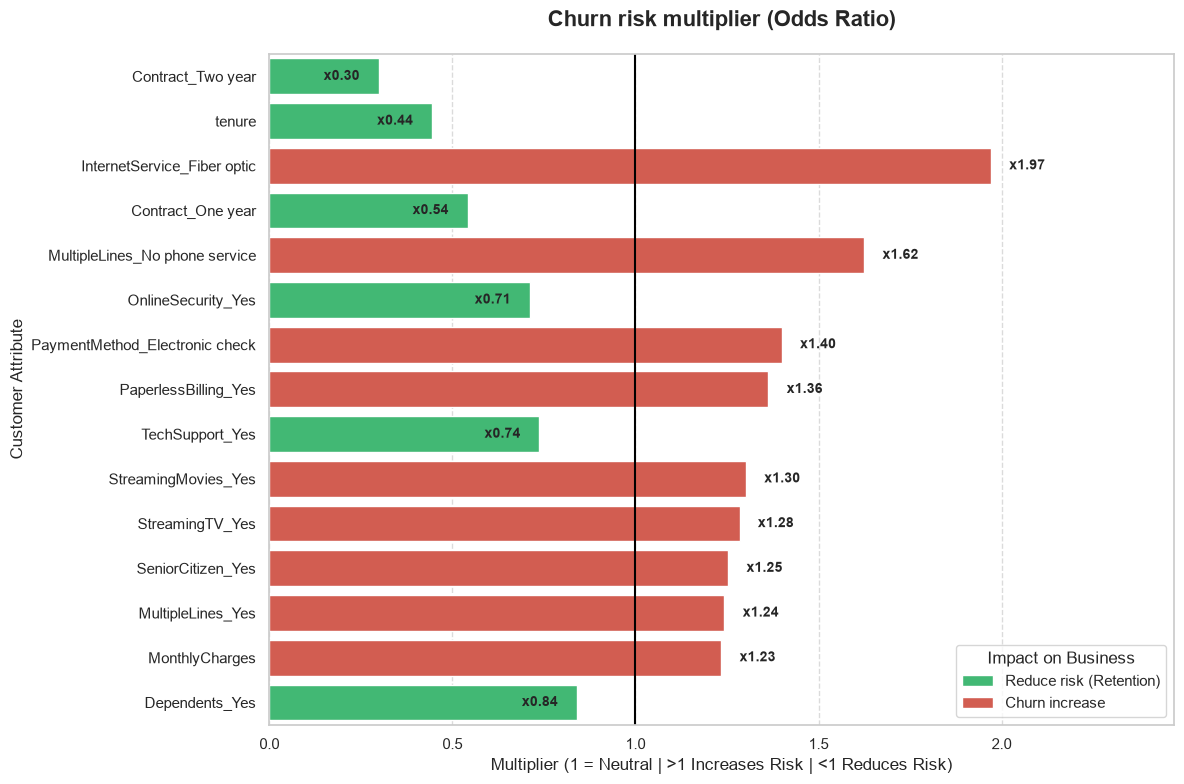

In [27]:
# ==============================================================================
# ODDS RATIO
# ==============================================================================



# Odds Ratio
df_coef['Odds_Ratio'] = np.exp(df_coef['Coeficiente'])

# Classify the effect based on the Odds Ratio
df_coef = df_coef.sort_values(by='Impacto_Absoluto', ascending=False)


plt.figure(figsize=(12, 8))
barplot = sns.barplot(
    data=df_coef, 
    x='Odds_Ratio', 
    y='Variable', 
    hue='Efecto',
    palette={'Churn increase': '#e74c3c', 'Reduce risk (Retention)': '#2ecc71'},
    dodge=False
)

plt.title('Churn risk multiplier (Odds Ratio)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Multiplier (1 = Neutral | >1 Increases Risk | <1 Reduces Risk)', fontsize=12)
plt.ylabel('Customer Attribute', fontsize=12)


plt.axvline(x=1, color='black', linestyle='-', linewidth=1.5)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for p in barplot.patches:
    width = p.get_width()
    if width > 0: 
        
        x_pos = width + 0.05 if width > 1 else width - 0.15
        plt.text(x_pos, p.get_y() + p.get_height()/2., 
                 f'x{width:.2f}', va='center', fontsize=10, fontweight='bold')

plt.legend(title='Impact on Business', loc='lower right')
plt.xlim(0, df_coef['Odds_Ratio'].max() + 0.5) 
plt.tight_layout()
plt.show()

By translating the model's multipliers (Odds Ratios) into business terms, we can precisely quantify how each attribute alters a customer's baseline risk of churn:

# 🔴 Primary Drivers of Churn (Increased Risk):

Fiber Optic: This is the critical churn factor. Subscribing to fiber optic internet practically doubles the risk of abandonment (a 97% increase) compared to other internet technologies.

No Phone Service: Customers who consume internet but lack phone service exhibit a 62% higher risk of churning.

Electronic Check: Using this transactional payment method increases the risk of churn by 40%.

# 🟢 Primary Anchors of Retention (Decreased Risk):

Long-Term Commitments: Extended contracts act as the company's most effective shield. Signing a two-year contract plummets the churn risk by 70%, while a one-year contract successfully reduces it by 46%.

Customer Loyalty and Tenure: Customer longevity serves as a strong mitigator. Established customers see their relative churn risk reduced by 56% for every significant increase (one standard deviation) in their tenure with the company.